In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets

# Question 1

In [2]:
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from scipy.linalg import svd

Variance: [40.31531029 29.92825299 11.26293476 10.44518175  8.04832021] 



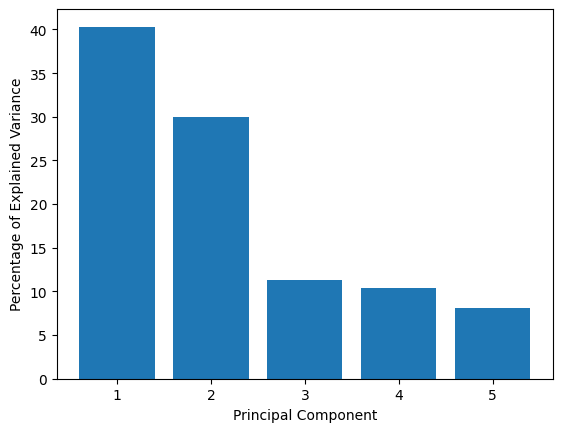

In [3]:
# Q1a

Q1_X = pd.read_csv("PADL-Q1.csv")
Q1_X = scale(Q1_X)                                          # scale the dataset

pca = PCA()
newX = pca.fit_transform(Q1_X)

# Plotting PC variances

variance = pca.explained_variance_ratio_*100
print("Variance:", variance, "\n")

plt.bar(x=range(1, len(variance)+1), height=variance)
plt.xlabel("Principal Component")
plt.ylabel("Percentage of Explained Variance")
plt.show()

In [4]:
# Q1a cont.

# Since the question is lacking context, it is difficult to allocate the suitable coverage threshold for this specific problem.
# Therefore, we are assuming cummulative variance coverage > 90% is decent enough
# to suggest that the dimensionality of the dataset is reduced with little to no information lost.

component = 0
total = 0

for i in variance:
  total += i
  if total > 90:
    component = np.where(variance == i)[0][0] + 1
    break

print(f"D_min = {component}")
print(f"""\nAlmost all ({total:.2f}%) of the variation is collectively along the first, second and third PCs.
Therefore, using at least PC1, PC2, PC3 and PC4 is enough to represent the original data.""")

D_min = 4

Almost all (91.95%) of the variation is collectively along the first, second and third PCs.
Therefore, using at least PC1, PC2, PC3 and PC4 is enough to represent the original data.


In [5]:
# Q1b

pca_2 = PCA()
newPC = pca_2.fit_transform(newX[:,:component])       # PCA analysis using D_min newX
print(newPC)

[[ 6.16580952e-01 -7.09138518e-01 -1.00167431e-01  2.44535762e-01]
 [ 2.22944660e+00  1.44951197e-01  1.01126055e+00 -1.02505875e+00]
 [ 1.28725304e+00 -1.77014769e-01 -8.80925689e-01 -1.81847989e+00]
 [ 1.05897151e+00  3.26447557e-01  4.58336738e-01  5.51786736e-01]
 [ 1.40761144e+00 -1.53340339e+00  7.07612466e-01 -1.05946377e-01]
 [-1.22108060e-01  6.80928734e-01  1.29288448e+00  5.85665057e-01]
 [ 7.28119076e-01  1.87710079e-01  9.53755091e-01 -9.44089663e-01]
 [-8.88299994e-01 -7.03491090e-01  5.61499493e-01  3.98401842e-01]
 [ 6.27981146e-01 -1.80320146e+00  6.49128602e-01  3.84206643e-01]
 [ 1.36468230e+00  5.30141699e-01 -9.33528319e-01 -4.55762640e-01]
 [-9.36999091e-01  8.19565680e-01  6.41474104e-01 -1.88419740e+00]
 [ 4.73799288e-01 -8.14482310e-01 -1.61047484e-01 -1.16459753e-01]
 [-2.27586940e+00  1.06933380e+00 -8.57342837e-01  3.24391119e-01]
 [-2.05030770e+00 -1.12669717e+00 -1.11497449e+00  4.36307597e-01]
 [ 1.40334576e+00  9.57844392e-01  6.75539118e-01  1.71104714e

In [6]:
# Q1b cont.

# Equations used to compute each principal component from the original variables

U, d, V = svd(Q1_X, full_matrices=False)
D = np.diag(d)
PC = np.matmul(U,D)
UDV = np.matmul(PC,V)

print("These equations are in decreasing order of the variance of the principal component they define, starting from the first column to last column.")

print('\nU =\n\n', U[:5])                                          # For easy-to-read purpose, only head(5) of U is shown below
print('\nD =\n\n', D)
print('\nPrincipal components = U x D :\n\n', PC[:5])              # For easy-to-read purpose, only head(5) of PC is shown below
print('\nV =\n\n', V)
print('\nX = U x D x V :\n\n', UDV[:5])                            # For easy-to-read purpose, only head(5) of UDV is shown below

a = np.round(np.absolute(newX), decimals=10)
b = np.round(np.absolute(PC), decimals=10)
print('\nCheck Principal Component:\t', np.array_equal(a, b))

c = np.round(Q1_X, decimals=10)
d = np.round(UDV, decimals=10)
print('Check UDV:\t\t\t', np.array_equal(c, d))

These equations are in decreasing order of the variance of the principal component they define, starting from the first column to last column.

U =

 [[ 0.03070825 -0.04099118 -0.00943845 -0.02392679 -0.08757693]
 [ 0.11103556  0.00837879  0.0952878   0.10029765 -0.05911578]
 [ 0.06411046 -0.0102322  -0.08300677  0.17793054 -0.00343555]
 [ 0.05274111  0.01887004  0.04318758 -0.05398999 -0.05157955]
 [ 0.0701048  -0.08863714  0.06667602  0.0103664  -0.06709415]]

D =

 [[20.07867284  0.          0.          0.          0.        ]
 [ 0.         17.2997841   0.          0.          0.        ]
 [ 0.          0.         10.61269747  0.          0.        ]
 [ 0.          0.          0.         10.2201672   0.        ]
 [ 0.          0.          0.          0.          8.97124306]]

Principal components = U x D :

 [[ 0.61658095 -0.70913852 -0.10016743 -0.24453576 -0.78567397]
 [ 2.2294466   0.1449512   1.01126055  1.02505875 -0.53034207]
 [ 1.28725304 -0.17701477 -0.88092569  1.81847989 -

# Question 2

In [7]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV

In [8]:
# Q2a

def regression(X, y, scale_option=None):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)
  if scale_option != None:
    # Apply scaling
    X_train, X_test = scale(scale_option, X_train, X_test, X.columns)
  # Train regression model
  model = build(X_train, X_test, y_train, y_test)
  return model

def polynomial(X, y, scale_option=None, degree=2):
  # Generate polynomial features
  X_poly, poly_cols = to_poly(degree, X)
  X_poly_train, X_poly_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=14)
  if scale_option != None:
    # Apply scaling
    X_poly_train, X_poly_test = scale(scale_option, X_poly_train, X_poly_test, poly_cols)
  # Train regression model
  model = build(X_poly_train, X_poly_test, y_train, y_test)
  return model

# Procedure to generate polynomial features
def to_poly(degree, X):
  poly = PolynomialFeatures(degree=degree)
  X_poly = poly.fit_transform(X)
  poly_cols = poly.get_feature_names_out(X.columns)
  X_poly = pd.DataFrame(X_poly, columns=poly_cols)
  return X_poly, poly_cols

def scale(option, X_train, X_test, cols):
  """
  Procedure to scale data based on options:
    "S" = Standardized
    "N" = Normalized
  """
  scaler = StandardScaler() if option == "S" else MinMaxScaler()
  scaler.fit(X_train)
  train = scaler.transform(X_train)
  test = scaler.transform(X_test)
  train = pd.DataFrame(train, columns=cols)
  test = pd.DataFrame(test, columns=cols)
  return train, test

# Procedure to train regression model
def build(X_train, X_test, y_train, y_test):
  model = LinearRegression()
  model.fit(X_train, y_train)
  r2 = model.score(X_test, y_test)
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  return {'model': model, 'mae': mae, 'mse': mse, 'r2': r2}

In [9]:
# Q2a cont.

data = pd.read_csv("PADL-Q2-train.csv")
Q2_X = data.drop(['out'], axis=1)
Q2_y = data['out']

none = regression(Q2_X, Q2_y, scale_option=None)
S = regression(Q2_X, Q2_y, scale_option='S')
N = regression(Q2_X, Q2_y, scale_option='N')

print("Linear Regression:\n")
print(f"Not scaled:\tMAE: {none['mae']:.4f}  |  MSE: {none['mse']:.4f}  |  R^2: {none['r2']*100:.14f}")
print(f"Standardized:\tMAE: {S['mae']:.4f}  |  MSE: {S['mse']:.4f}  |  R^2: {S['r2']*100:.14f}")
print(f"Normalized:\tMAE: {N['mae']:.4f}  |  MSE: {N['mse']:.4f}  |  R^2: {N['r2']*100:.14f}")

for i in range(2,5):
  none = polynomial(Q2_X, Q2_y, scale_option=None, degree=i)
  S = polynomial(Q2_X, Q2_y, scale_option='S', degree=i)
  N = polynomial(Q2_X, Q2_y, scale_option='N', degree=i)
  print(f"\n{i}-order Polynomial Regression:\n")
  print(f"Not scaled:\tMAE: {none['mae']:.4f}  |  MSE: {none['mse']:.4f}  |  R^2: {none['r2']*100:.14f}")
  print(f"Standardized:\tMAE: {S['mae']:.4f}  |  MSE: {S['mse']:.4f}  |  R^2: {S['r2']*100:.14f}")
  print(f"Normalized:\tMAE: {N['mae']:.4f}  |  MSE: {N['mse']:.4f}  |  R^2: {N['r2']*100:.14f}")

Linear Regression:

Not scaled:	MAE: 0.0742  |  MSE: 0.0101  |  R^2: 42.72316212648860
Standardized:	MAE: 0.0742  |  MSE: 0.0101  |  R^2: 42.72316212648467
Normalized:	MAE: 0.0742  |  MSE: 0.0101  |  R^2: 42.72316212648472

2-order Polynomial Regression:

Not scaled:	MAE: 0.0696  |  MSE: 0.0066  |  R^2: 62.58523067464956
Standardized:	MAE: 0.0696  |  MSE: 0.0066  |  R^2: 62.58523067464730
Normalized:	MAE: 0.0696  |  MSE: 0.0066  |  R^2: 62.58523067464741

3-order Polynomial Regression:

Not scaled:	MAE: 0.5925  |  MSE: 0.5794  |  R^2: -3192.34288630646506
Standardized:	MAE: 0.0967  |  MSE: 0.0157  |  R^2: 10.70915439277567
Normalized:	MAE: 0.1259  |  MSE: 0.0261  |  R^2: -48.14761011244639

4-order Polynomial Regression:

Not scaled:	MAE: 0.3312  |  MSE: 0.1943  |  R^2: -1004.12023508438631
Standardized:	MAE: 0.3312  |  MSE: 0.1943  |  R^2: -1004.12001046838930
Normalized:	MAE: 0.3312  |  MSE: 0.1943  |  R^2: -1004.12001046447460


In [10]:
# Q2a cont.

print("2-order Polynomial Regression yields the least errors and best result among the models.")
print("This model without scaling yields the (least errors and) best result.")

2-order Polynomial Regression yields the least errors and best result among the models.
This model without scaling yields the (least errors and) best result.


In [11]:
# Q2b

# Updated version of the above "regression" procedure. Regularisation options are now part of the procedure.
def regression_2(X, y, scale_option=None, model_option="LR"):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)
  if scale_option != None:
    X_train, X_test = scale(scale_option, X_train, X_test, X.columns)
  model = build_2(X_train, X_test, y_train, y_test, model_option)
  return model

# Updated version of the above "polynomial" procedure. Regularisation options are now part of the procedure.
def polynomial_2(X, y, scale_option=None, model_option="LR", degree=2):
  X_poly, poly_cols = to_poly(degree, X)
  X_poly_train, X_poly_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=14)
  if scale_option != None:
    X_poly_train, X_poly_test = scale(scale_option, X_poly_train, X_poly_test, poly_cols)
  model = build_2(X_poly_train, X_poly_test, y_train, y_test, model_option)
  return model

# Updated version of the above "build" procedure. Regularisation options are added to the procedure.
def build_2(X_train, X_test, y_train, y_test, model_option="LR"):
  """
  Regularisation options:
    "LR" = Regression without regularisation
    "L1" = Lasso Regression
    "L2" = Ridge Regression
    "L1_CV" = L1 with Cross-validation
    "L2_CV" = L2 with Cross-validation
  """
  model = LinearRegression() if model_option=="LR" else Lasso() if model_option=="L1" else Ridge() if model_option=="L2" else LassoCV(cv=3) if model_option=="L1_CV" else RidgeCV(cv=3)
  model.fit(X_train, y_train)
  r2 = model.score(X_test, y_test)
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  return {'model': model, 'mae': mae, 'mse': mse, 'r2': r2}

In [12]:
# Q2b cont.

for i in ["LR", "L1", "L2", "L1_CV", "L2_CV"]:
  Q2_model = polynomial_2(Q2_X, Q2_y, scale_option=None, model_option=i, degree=2)
  print(f"2-order Polynomial Regression, Not scaled, {i}:     \tMAE: {Q2_model['mae']:.4f}  |  MSE: {Q2_model['mse']:.4f}  |  R^2: {Q2_model['r2']*100:.14f}\n")

2-order Polynomial Regression, Not scaled, LR:     	MAE: 0.0696  |  MSE: 0.0066  |  R^2: 62.58523067464956

2-order Polynomial Regression, Not scaled, L1:     	MAE: 0.0955  |  MSE: 0.0151  |  R^2: 13.92282696886630

2-order Polynomial Regression, Not scaled, L2:     	MAE: 0.0750  |  MSE: 0.0098  |  R^2: 44.27359996675505

2-order Polynomial Regression, Not scaled, L1_CV:     	MAE: 0.0886  |  MSE: 0.0131  |  R^2: 25.27971093402163

2-order Polynomial Regression, Not scaled, L2_CV:     	MAE: 0.0697  |  MSE: 0.0085  |  R^2: 51.57761977920998



In [13]:
# Q2b cont.

print("This model without regularisation yields the best result.")

This model without regularisation yields the best result.


In [14]:
# Q2c

data = pd.read_csv("PADL-Q2-train.csv")
Q2_X = data.drop(['out'], axis=1)
Q2_y = data['out']

def automation(X, y):
  score = 0
  degree = 0
  scaling = ""
  regularisation = ""

  for i in ["LR", "L1", "L2", "L1_CV", "L2_CV"]:
    for j in (None, "S", "N"):
      model = regression_2(X, y, scale_option=j, model_option=i)
      if (model["r2"]>score):
        score = model["r2"]
        degree = 0
        scaling = j
        regularisation = i
      for k in range(2,5):
        model = polynomial_2(X=X, y=y, scale_option=j, model_option=i, degree=k)
        if (model["r2"]>score):
          score = model["r2"]
          degree = k
          scaling = j
          regularisation = i

  if (degree > 0):
    model = polynomial_2(X, y, scale_option=scaling, model_option=regularisation, degree=degree)
  else:
    model = regression_2(X, y, scale_option=scaling, model_option=regularisation)

  return {"model": model, "degree": degree, "scaling": scaling, "regularisation": regularisation}

chosen = automation(Q2_X, Q2_y)
model_name = (str(chosen["degree"]) + "-order Polynomial Regression") if chosen["degree"]>0 else "Linear Regression"
print("\n{}, Scaling: {}, Regularisation: {}".format(model_name, chosen["scaling"], chosen["regularisation"]))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.316e-01, tolerance: 9.603e-05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.33763603043758e-05, tolerance: 6.867365460465118e-05
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to incre


2-order Polynomial Regression, Scaling: None, Regularisation: LR


In [ ]:
# Q2c cont.
# Run this tile again for the unseen data

data = pd.read_csv("PADL-Q2-unseen.csv")
Q2_X = data.drop(['out'], axis=1)
Q2_y = data['out']

chosen = automation(Q2_X, Q2_y)
model_name = (str(chosen["degree"]) + "-order Polynomial Regression") if chosen["degree"]>0 else "Linear Regression"
print("\n{}, Scaling: {}, Regularisation: {}".format(model_name, chosen["scaling"], chosen["regularisation"]))

# Question 3

In [15]:
import requests
from gensim import downloader as api
from gensim.models import Word2Vec

In [16]:
# Q3a

link = "https://www.gutenberg.org/cache/epub/48320/pg48320.txt"
data = requests.get(link).text
filters = ['\ufeff', "\u2002", ","]

# Procedure for data cleaning

def clean(text, filters):
  sentences = text.split("\n")
  new = []
  for sentence in sentences:
    for f in filters:
      sentence = sentence.replace(f, "")
    new.append(sentence.replace("-"," ").strip())                   # splitting each of the hyphenated terms into two instead of merging
  return [s.lower() for s in new if s!=""]                          # return non-empty sentences

sentences = clean(data, filters)                                    # store the cleaned text in a variable for later use

# Procedure that extracts all triplets of words where the word in the middle is 'and'

def find_triplets(sentences):
  triplets = []
  for sentence in sentences:                                        # for each of the sentences
    temp = sentence.split(" ")                                      # break the sentence down into a list of words
    while "and" in temp:
      start = temp.index("and")-1
      end = temp.index("and")+2
      triplets.append(temp[start:end])
      temp.remove("and")                                            # remove the current "and" to find the next in the list
  return [triplet for triplet in triplets if len(triplet)==3]       # return triplets only

# Procedure that complies to Q3a

def Q3a(text, filters):
  return find_triplets(clean(text, filters))

triplets = Q3a(data, filters)                                       # store all the triplets into a variable for later use
triplets

[['cost', 'and', 'with'],
 ['shut', 'and', 'locked”'],
 ['bye', 'and', 'be'],
 ['emotions', 'and', 'that'],
 ['reasoning', 'and', 'observing'],
 ['motives', 'and', 'actions.'],
 ['him', 'and', 'that'],
 ['dubious', 'and', 'questionable'],
 ['happiness', 'and', 'the'],
 ['books', 'and', 'alternating'],
 ['drug', 'and', 'the'],
 ['crime', 'and', 'occupied'],
 ['faculties', 'and', 'extraordinary'],
 ['clues', 'and', 'clearing'],
 ['friend', 'and', 'companion.'],
 ['again', 'and', 'to'],
 ['lit', 'and', 'even'],
 ['chest', 'and', 'his'],
 ['mood', 'and', 'habit'],
 ['attitude', 'and', 'manner'],
 ['dreams', 'and', 'was'],
 ['bell', 'and', 'was'],
 ['cigars', 'and', 'indicated'],
 ['case', 'and', 'a'],
 ['fire', 'and', 'looked'],
 ['seven', 'and', 'a'],
 ['watson.', 'and', 'in'],
 ['lately', 'and', 'that'],
 ['clumsy', 'and', 'careless'],
 ['thursday', 'and', 'came'],
 ['incorrigible', 'and', 'my'],
 ['himself', 'and', 'rubbed'],
 ['forefinger', 'and', 'a'],
 ['process.', 'and', 'yet'],
 ['

In [17]:
# Q3b

L = ['gold', 'diamond', 'robbery', 'bank', 'police']          # list L, given in the question, is used as an example

# Procedure that complies to Q3b

def Q3b(index, L, triplets):
  W = L[index-1]                                              # first word = 'gold', second word = 'diamond', third word = 'robbery', etc.
  suffix = W[-3:]                                             # extract W suffix of length (at least) 3
  ans = []
  for triplet in triplets:
    last = triplet[-1]                                        # extract last of the three words in the triplet
    if last[-3:] == suffix:                                   # check if last of the three words in the triplet and W share the suffix
      ans.append(triplet)
  return ans

# Demonstration

Q3b(3, L, triplets)                                           # taking word 'robbery' from list L

[['delicacy', 'and', 'every'],
 ['ten', 'and', 'every'],
 ['police', 'and', 'every'],
 ['air', 'and', 'scenery'],
 ['long', 'and', 'very'],
 ['chair', 'and', 'cheery'],
 ['police', 'and', 'very']]

In [18]:
# Q3c

# Load the glove-wiki-gigaword-100 pre-trained word2vec model
Q3_model = api.load("glove-wiki-gigaword-100")

Q3_model_2 = Word2Vec(vector_size=100, min_count=1, epochs=50)
Q3_model_2.build_vocab([sentence.split(" ") for sentence in sentences])
total_examples = Q3_model_2.corpus_count
Q3_model_2.build_vocab([list(Q3_model.key_to_index.keys())], update=True)

Q3_model_2.wv.vectors_lockf = np.ones(len(Q3_model_2.wv))

# Train the model again with the new dataset.
Q3_model_2.train([sentence.split(" ") for sentence in sentences], total_examples=total_examples, epochs=Q3_model_2.epochs)
word_embeddings = Q3_model_2.wv                     # Embeddings are stored as KeyedVectors


# Procedure that computes the semantic similarity between the first and third word in the triplet

def similarity(triplet):
  return np.dot(word_embeddings[triplet[0]], word_embeddings[triplet[2]])

# Procedure that complies to Q3c

def Q3c(L, triplets):
  ans = {}
  for i in range(1,len(L)+1):                               # for each word W and ...
    T = Q3b(i, L, triplets)                                 # corresponding list of triplets selected in the previous step
    T.sort(reverse=True, key=similarity)                    # compute similarity and sort the triplets in order of decreasing similarity
    ans[L[i-1]] = T[:5]                                     # return the top 5 triplets
  return ans

# Demonstration

demo = Q3c(L, triplets)                                     # using list L
for i in demo:
  print(f"\n{i}: {demo[i]}")

[==================================================] 100.0% 128.1/128.1MB downloaded

gold: [['rapidly', 'and', 'told'], ['indemnify', 'and', 'hold'], ['silk', 'and', 'gold'], ['away', 'and', 'told']]

diamond: []

robbery: [['chair', 'and', 'cheery'], ['long', 'and', 'very'], ['air', 'and', 'scenery'], ['delicacy', 'and', 'every'], ['ten', 'and', 'every']]

bank: [['do', 'and', 'frank'], ['mercifully', 'and', 'thank']]

police: []


# Question 4

In [25]:
# Q4a

class LinearRegressionModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return torch.exp(self.layers(torch.log(x)))

Q4_model = LinearRegressionModel(2, 1, hidden_units=40)
Q4_model.load_state_dict(torch.load('Q4.pkl'))
Q4_model.state_dict()

OrderedDict([('layers.0.weight',
              tensor([[ 8.5745e-04,  8.9745e-04],
                      [-6.0306e-04, -6.1510e-04],
                      [ 9.5380e-04,  9.3867e-04],
                      [ 8.0841e-04,  8.1989e-04],
                      [-3.6498e-04, -3.6460e-04],
                      [-8.2816e-04, -8.2395e-04],
                      [-7.7758e-04, -7.8206e-04],
                      [-3.4672e-04, -3.4919e-04],
                      [-6.8940e-04, -6.8682e-04],
                      [-7.7556e-04, -7.7545e-04],
                      [ 7.5862e-04,  7.9735e-04],
                      [ 8.2372e-04,  8.4095e-04],
                      [ 8.7224e-04,  8.5314e-04],
                      [ 4.6158e-04,  1.2207e-04],
                      [ 8.7781e-04,  8.7791e-04],
                      [-4.4368e-04, -4.4271e-04],
                      [-5.7231e-04, -5.8633e-04],
                      [-4.1092e-04, -4.0974e-04],
                      [ 7.7967e-04,  8.0312e-04],
                 

In [26]:
# Q4b

Q4_X = np.random.randint(2,102,(1000,2))
Q4_y = Q4_X[:,0] * Q4_X[:,1]

Q4_X = torch.tensor(Q4_X).type(torch.float)
Q4_y = torch.tensor(Q4_y).type(torch.float)

Q4_X_train, Q4_X_test, Q4_y_train, Q4_y_test = train_test_split(Q4_X, Q4_y, test_size=0.2, random_state=23)

# 0.8 x 1000 = 800 random entries are used for training. The training data are all POSITIVE WHOLE numbers between 2 and 102.

In [27]:
# Q4b cont.

Q4_criterion = nn.MSELoss()
Q4_optimizer = torch.optim.SGD(Q4_model.parameters(), lr=0.001)

def L1regloss(model):
  reg_loss = 0
  for param in model.parameters():
    reg_loss += param.abs().sum()
  return reg_loss

In [ ]:
# Q4b cont.

epochs = 120001

for epoch in range(epochs):

  # Set the model into training mode
  Q4_model.train()

  # Forward pass train data
  y_pred = Q4_model(torch.log(Q4_X_train))

  # Calculate loss with Regularisation
  fit_loss = Q4_criterion(y_pred, torch.log(Q4_y_train.unsqueeze(dim=1)))
  reg_loss = L1regloss(Q4_model)
  loss = fit_loss + reg_loss
  # loss = criterion(y_pred, torch.log(y_train.unsqueeze(dim=1)))

  # Optimizer zero grad
  Q4_optimizer.zero_grad()

  # Backward propagation
  loss.backward()

  # Optimizer step
  Q4_optimizer.step()

  # Set the model into non-training mode
  Q4_model.eval()

  with torch.inference_mode():
    # Forward pass test data
    test_pred = Q4_model(torch.log(Q4_X_test))

    # Calculate loss
    test_loss = Q4_criterion(test_pred, torch.log(Q4_y_test.unsqueeze(dim=1)))

    if epoch % 10000 == 0:
      print(f"Epoch: {epoch} | Train Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train Loss: 3.638479471206665 | Test loss: 0.029274100437760353
Epoch: 10000 | Train Loss: 3.6896584033966064 | Test loss: 0.025201210752129555
Epoch: 20000 | Train Loss: 3.7039430141448975 | Test loss: 0.02520875632762909
Epoch: 30000 | Train Loss: 3.717878818511963 | Test loss: 0.025484057143330574
Epoch: 40000 | Train Loss: 3.7222461700439453 | Test loss: 0.025489702820777893
Epoch: 50000 | Train Loss: 3.702453136444092 | Test loss: 0.024301061406731606
Epoch: 60000 | Train Loss: 3.712127208709717 | Test loss: 0.024103904142975807
Epoch: 70000 | Train Loss: 3.720357894897461 | Test loss: 0.0240519717335701
Epoch: 80000 | Train Loss: 3.7177884578704834 | Test loss: 0.02556416764855385
Epoch: 90000 | Train Loss: 3.7259092330932617 | Test loss: 0.025580372661352158
Epoch: 100000 | Train Loss: 3.717132329940796 | Test loss: 0.02559840865433216
Epoch: 110000 | Train Loss: 3.7296736240386963 | Test loss: 0.026145152747631073
Epoch: 120000 | Train Loss: 3.7315902709960938 | Test

In [28]:
# torch.save(Q4_model.state_dict(), 'Q4.pkl')

In [36]:
# Q4c

y_pred = torch.exp(Q4_model(torch.log(Q4_X_test))).detach().numpy()
r2_within = r2_score(Q4_y_test, y_pred)
mae_within = mean_absolute_error(Q4_y_test, y_pred)

# Create dataset outside of training range:

Q4_X_outside = np.random.randint(103,203,(200,2))       # 0.2 * 1000 = 200
Q4_y_outside = Q4_X_outside[:,0] * Q4_X_outside[:,1]

Q4_X_outside = torch.tensor(Q4_X_outside).type(torch.float)
Q4_y_outside = torch.tensor(Q4_y_outside).type(torch.float)

y_pred = torch.exp(Q4_model(torch.log(Q4_X_outside))).detach().numpy()
r2_outside = r2_score(Q4_y_outside, y_pred)
mae_outside = mean_absolute_error(Q4_y_outside, y_pred)

print(f"Metrics within the training range\tR^2: {r2_within} | Mean Error: {mae_within}")
print(f"Metrics outside the training range\tR^2: {r2_outside} | Mean Error: {mae_outside}")

Metrics within the training range	R^2: 0.9805214350768631 | Mean Error: 190.7681427001953
Metrics outside the training range	R^2: 0.1391537555938852 | Mean Error: 5615.91455078125


# Question 5

In [44]:
import os
from skimage import io

In [ ]:
# Q5a

batches = np.arange(0, 10000, 1, dtype=int)

Q5_X = [str(b).rjust(4, '0') + '.png' for b in batches]

root_dir = "clocks_dataset\\train"
Q5_y = []
for i in batches:
    name = str(i).rjust(4, '0') + '.txt'
    with open("{}\\{}".format(root_dir,name)) as f:
        content = f.read()
    Q5_y.append(content)

vocab = {}
for h in range(12):
    for m in range(60):
        time = "{}:{}".format(str(h).rjust(2, '0'), str(m).rjust(2, '0'))
        vocab[time] = h*60+m

y_enc = []
for i in Q5_y:
    y_enc.append(vocab[i])

df = pd.DataFrame(data={'X': Q5_X, 'y_enc': y_enc})

In [ ]:
# Q5a cont.

class ClocksDataset(Dataset):

    def __init__(self, df, root_dir, transform=None):
        self.annotations = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_name = os.path.join(self.root_dir, self.annotations.iloc[index, 0])
        image = io.imread(img_name)
        y = torch.tensor(self.annotations.iloc[index, 1])

        if self.transform:
            image = self.transform(image)

        return (image, y)

In [ ]:
# Q5a cont.

dataset = ClocksDataset(df = df, root_dir = root_dir, transform = transforms.ToTensor())
train_set, val_set = random_split(dataset, [0.875, 0.125])

train_loader = DataLoader(dataset=train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(dataset=val_set, batch_size=128, shuffle=True)

In [ ]:
# Q5b

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.maxpool = nn.MaxPool2d(kernel_size=4, stride=2)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=12, stride=4, padding=0)
        self.conv2 = nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(in_features=256*12*12, out_features=4096)
        self.fc2 = nn.Linear(in_features=4096, out_features=4096)
        self.fc3 = nn.Linear(in_features=4096, out_features=len(vocab))

    def forward(self, x):
        # Input x has dimensions B x 3 x 448 x 448, B is batch size
        x = self.relu(self.conv1(x))
        # B x 96 x 110 x 110
        x = self.maxpool(x)
        # B x 96 x 54 x 54
        x = self.relu(self.conv2(x))
        # B x 256 x 54 x 54
        x = self.maxpool(x)
        # B x 256 x 26 x 26
        x = self.relu(self.conv3(x))
        # B x 384 x 26 x 26
        x = self.relu(self.conv4(x))
        # B x 384 x 26 x 26
        x = self.relu(self.conv5(x))
        # B x 256 x 26 x 26
        x = self.maxpool(x)
        # B x 256 x 12 x 12
        x = x.view(x.size(0), -1)
        # Flattened to B x 36864
        x = self.dropout(self.relu(self.fc1(x)))
        # B x 4096
        x = self.dropout(self.relu(self.fc2(x)))
        # B x 4096
        x = self.fc3(x)
        # B x 720
        return x

model = CNN()

model.load_state_dict(torch.load('weights.pkl'))

In [49]:
# Q5c

loss_func = nn.CrossEntropyLoss()

print("Cross-entropy is suitable and used as the loss function for our model.\nThe loss function is used to minimize the error between the predicted probability distribution and true distribution.")

Cross-entropy is suitable and used as the loss function for our model.
The loss function is used to minimize the error between the predicted probability distribution and true distribution.


In [ ]:
# Q5d

optim = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)

iterations_per_epoch = len(train_loader)
num_epochs = 90

for epoch in range(num_epochs):
    total_loss = 0
    for i, (images, labels) in enumerate(train_loader):
        output = model(images)
        loss = loss_func(output,labels)
        optim.zero_grad()
        loss.backward()
        optim.step()
        if (i+1) % 34 == 0:
            print('Epoch [{}/{}], Iteration [{}/{}], Loss: {:.4f}'.format(epoch + 1, num_epochs, i + 1, iterations_per_epoch, loss.item()))
        total_loss += loss
    print('Total loss over epoch {}: {:.2f}'.format(epoch+1,total_loss))


Screenshot for the above tile:

```
Epoch [1/90], Iteration [34/69], Loss: 6.5372
Epoch [1/90], Iteration [68/69], Loss: 6.5245
Total loss over epoch 1: 451.23
Epoch [2/90], Iteration [34/69], Loss: 6.5636
Epoch [2/90], Iteration [68/69], Loss: 6.5179
Total loss over epoch 2: 451.24
Epoch [3/90], Iteration [34/69], Loss: 6.5822
Epoch [3/90], Iteration [68/69], Loss: 6.4957
Total loss over epoch 3: 451.24
Epoch [4/90], Iteration [34/69], Loss: 6.5357
Epoch [4/90], Iteration [68/69], Loss: 6.5377
Total loss over epoch 4: 451.24
Epoch [5/90], Iteration [34/69], Loss: 6.5915
Epoch [5/90], Iteration [68/69], Loss: 6.5481
Total loss over epoch 5: 451.31
Epoch [6/90], Iteration [34/69], Loss: 6.5113
Epoch [6/90], Iteration [68/69], Loss: 6.5233
Total loss over epoch 6: 451.30
Epoch [7/90], Iteration [34/69], Loss: 6.5265
Epoch [7/90], Iteration [68/69], Loss: 6.5258
Total loss over epoch 7: 451.22
Epoch [8/90], Iteration [34/69], Loss: 6.5463
Epoch [8/90], Iteration [68/69], Loss: 6.5044
Total loss over epoch 8: 451.27
Epoch [9/90], Iteration [34/69], Loss: 6.4978
Epoch [9/90], Iteration [68/69], Loss: 6.5360
Total loss over epoch 9: 451.22
Epoch [10/90], Iteration [34/69], Loss: 6.5650
Epoch [10/90], Iteration [68/69], Loss: 6.5383
Total loss over epoch 10: 451.22
Epoch [11/90], Iteration [34/69], Loss: 6.5416
Epoch [11/90], Iteration [68/69], Loss: 6.5623
Total loss over epoch 11: 451.19
Epoch [12/90], Iteration [34/69], Loss: 6.5323
Epoch [12/90], Iteration [68/69], Loss: 6.5117
Total loss over epoch 12: 451.31
Epoch [13/90], Iteration [34/69], Loss: 6.5288
Epoch [13/90], Iteration [68/69], Loss: 6.5471
Total loss over epoch 13: 451.24
Epoch [14/90], Iteration [34/69], Loss: 6.5413
Epoch [14/90], Iteration [68/69], Loss: 6.5552
Total loss over epoch 14: 451.23
Epoch [15/90], Iteration [34/69], Loss: 6.5575
Epoch [15/90], Iteration [68/69], Loss: 6.5488
Total loss over epoch 15: 451.25
Epoch [16/90], Iteration [34/69], Loss: 6.5242
Epoch [16/90], Iteration [68/69], Loss: 6.5466
Total loss over epoch 16: 451.24
Epoch [17/90], Iteration [34/69], Loss: 6.5338
Epoch [17/90], Iteration [68/69], Loss: 6.5254
Total loss over epoch 17: 451.27
Epoch [18/90], Iteration [34/69], Loss: 6.5385
Epoch [18/90], Iteration [68/69], Loss: 6.5307
Total loss over epoch 18: 451.24
Epoch [19/90], Iteration [34/69], Loss: 6.5342
Epoch [19/90], Iteration [68/69], Loss: 6.5250
Total loss over epoch 19: 451.28
Epoch [20/90], Iteration [34/69], Loss: 6.5440
Epoch [20/90], Iteration [68/69], Loss: 6.5044
Total loss over epoch 20: 451.29
Epoch [21/90], Iteration [34/69], Loss: 6.5657
```



In [46]:
# torch.save(model.state_dict(), 'weights.pkl')

In [ ]:
# Code and implementation attempted for Q5e

correct = 0
total = 0
for images, labels in val_loader:
    output = model(images) # B x 10
    pred_y = torch.argmax(output, 1) # B
    correct += (pred_y == labels).sum()
    total += float(labels.size(0))
accuracy = correct/total
print('Test Accuracy of the model on the 10000 test images: %.2f' % accuracy)

# Question 6

In [40]:
# Q6a

batch_size = 128
nc = 3      # RGB channels
nZ = 100
nG = 64
nD = 64

def nGdiv(x):
    return int(nG/x)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.generator = nn.Sequential(
            # Input z has dimension 100 x 1
            self.block(nZ, nG*16, 4, 1, 0),
            # 1024 x 4 x 4
            self.block(nG*16, nG*8, 4, 2, 1),
            # 512 x 8 x 8
            self.block(nG*8, nG*4, 4, 2, 1),
            # 256 x 16 x 16
            self.block(nG*4, nG*2, 4, 2, 1),
            # 128 x 32 x 32
            self.block(nG*2, nG, 4, 2, 1),
            # 64 x 64 x 64
            self.block(nG, nGdiv(2), 4, 2, 1),
            # 32 x 128 x 128
            self.block(nGdiv(2), nGdiv(4), 4, 2, 1),
            # 16 x 256 x 256
            nn.ConvTranspose2d(nGdiv(4), nc, 4, 2, 33, bias=False),
            # 3 x 448 x 448
            nn.Tanh(),
        )

    def block(self, in_channels, out_channels, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.generator(x)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.discriminator = nn.Sequential(
            # Input x has dimension 3 x 448 x 448
            nn.Conv2d(nc, nGdiv(4), 4, 2, 33, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 16 x 256 x 256
            self.block(nGdiv(4), nGdiv(2), 4, 2, 1),
            # 32 x 128 x 128
            self.block(nGdiv(2), nD, 4, 2, 1),
            # 64 x 64 x 64
            self.block(nD, nD*2, 4, 2, 1),
            # 128 x 32 x 32
            self.block(nD*2, nD*4, 4, 2, 1),
            # 256 x 16 x 16
            self.block(nD*4, nD*8, 4, 2, 1),
            # 512 x 8 x 8
            self.block(nD*8, nD*16, 4, 2, 1),
            # 1024 x 4 x 4
            nn.Conv2d(nD*16, nZ, 4, 1, 0, bias=False),
            # 100 x 1
            nn.Sigmoid(),
        )

    def block(self, in_channels, out_channels, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.discriminator(x)

generator = Generator()
discriminator = Discriminator()

In [ ]:
# Code and implementation attempted for Q6b

workers = 2
dataroot = "clocks_dataset"

x = lambda file : file.endswith("png")

dataset = datasets.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]),
                           is_valid_file = x)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=workers)

In [ ]:
# Q6b cont.

beta1 = 0.5
lr = 0.0002

real_label = 1.
fake_label = 0.

criterion = nn.BCELoss()
optimizerD = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))

num_epochs = 5

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader):
        images = data[0]
        batch_size = images.size(0)

        ## Update Discriminator

        discriminator.zero_grad()

        # Train with all-real batch
        label = torch.full((batch_size,), real_label, dtype=torch.float)

        output = discriminator(images).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Train with all-fake batch
        noise = torch.randn(batch_size, nZ, 1, 1)
        fake = generator(noise)
        label.fill_(fake_label)

        output = (fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        ## Update Generator

        generator.zero_grad()
        label.fill_(real_label)

        output = discriminator(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'%(epoch, num_epochs, i, len(dataloader), errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

In [ ]:
# Code and implementation attempted for Q6c

fixed_noise = torch.randn(8, nZ, 1, 1)

with torch.no_grad():
    fake = generator(fixed_noise).detach()

fig = plt.figure(figsize=(8,8))
plt.axis("off")
plt.imshow(fake)

In [ ]:
# Code and implementation attempted for Q6d

nsamples = 9
z1 = torch.randn(1, nZ, 1, 1)
z2 = torch.randn(1, nZ, 1, 1)
z = torch.zeros(nsamples,nZ,1,1)
for i in range(nsamples):
  w1 = i/(nsamples-1)
  w2 = 1-w1
  z[i,:,:,:] = w1*z1 + w2*z2
images = generator(z)

figure = plt.figure(figsize=(12, 4))
for i in range(nsamples):
    figure.add_subplot(1, nsamples, i+1)
    plt.axis("off")
    plt.imshow(0.5-0.5*images[i,:].squeeze().detach(), cmap="gray")
plt.show()